# Baseline SVM Model (Hierarchical Pipeline)
This notebook establishes the baseline performance for the RBL Requirements Classification using a traditional machine learning approach (TF-IDF + Support Vector Machine).

We implement a **Two-Step Hierarchical Pipeline**:
1. **Step 1 (Binary Classification):** Predict if a requirement is Functional (FR) or Non-Functional (NFR).
2. **Step 2 (Multi-class Classification):** If NFR, use a secondary model and SMOTE (or Class Weights) to predict the specific NFR subcategory.

In [1]:
import pandas as pd
import numpy as np
import time
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from collections import Counter
import joblib

## 1. Load Data

In [2]:
data_dir = '../data/processed'
train_df = pd.read_csv(f"{data_dir}/train.csv")
val_df = pd.read_csv(f"{data_dir}/val.csv")
test_df = pd.read_csv(f"{data_dir}/test.csv")

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 1590
Validation size: 341
Test size: 341


## 2. Feature Engineering (TF-IDF)
We fit the TF-IDF vectorizer only on the Training set to prevent data leakage.

In [3]:
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))

X_train_tfidf = vectorizer.fit_transform(train_df['text'])
X_test_tfidf = vectorizer.transform(test_df['text'])

y_train_binary = train_df['label_binary']
y_test_binary = test_df['label_binary']

print(f"TF-IDF Matrix shape: {X_train_tfidf.shape}")

TF-IDF Matrix shape: (1590, 5000)


## 3. Step 1: Binary Classification (FR vs NFR)
Train an SVM with a linear kernel to differentiate between FR and NFR.

In [4]:
svm_binary = SVC(kernel='linear', random_state=42)

start_time = time.time()
svm_binary.fit(X_train_tfidf, y_train_binary)
train_time_binary = time.time() - start_time

print(f"Binary Model Training Time: {train_time_binary:.4f} seconds")

Binary Model Training Time: 0.2238 seconds


Accuracy (Binary): 0.9120

Classification Report (Binary):
              precision    recall  f1-score   support

          FR       0.90      0.94      0.92       179
         NFR       0.93      0.88      0.91       162

    accuracy                           0.91       341
   macro avg       0.91      0.91      0.91       341
weighted avg       0.91      0.91      0.91       341



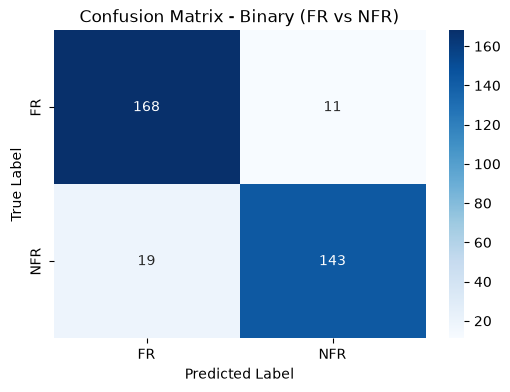

In [5]:
y_pred_binary = svm_binary.predict(X_test_tfidf)

acc_binary = accuracy_score(y_test_binary, y_pred_binary)
print(f"Accuracy (Binary): {acc_binary:.4f}")
print("\nClassification Report (Binary):")
print(classification_report(y_test_binary, y_pred_binary))

# Confusion Matrix
cm_binary = confusion_matrix(y_test_binary, y_pred_binary, labels=['FR', 'NFR'])
plt.figure(figsize=(6,4))
sns.heatmap(cm_binary, annot=True, fmt='d', cmap='Blues', xticklabels=['FR', 'NFR'], yticklabels=['FR', 'NFR'])
plt.title("Confusion Matrix - Binary (FR vs NFR)")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## 4. Step 2: Multi-class Classification (sub_NFR) - SMOTE
Filter for NFRs only. Apply SMOTE to balance the subcategories, then train a multi-class SVM.

In [6]:
# Isolate NFRs for Training
train_nfr_mask = (train_df['label_binary'] == 'NFR').values
X_train_nfr_tfidf = X_train_tfidf[train_nfr_mask]
y_train_nfr = train_df.loc[train_nfr_mask, 'sub_NFR'].reset_index(drop=True)

print("Before SMOTE:", dict(Counter(y_train_nfr)))

# Apply SMOTE
# k_neighbors=3 because some classes (like PO) might have very few samples
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_nfr_tfidf, y_train_nfr)

print("After SMOTE:", dict(Counter(y_train_resampled)))

Before SMOTE: {'A': 62, 'FT': 20, 'SE': 152, 'O': 115, 'US': 105, 'LF': 73, 'PE': 112, 'SC': 28, 'MN': 42, 'L': 34, 'PO': 15}
After SMOTE: {'A': 152, 'FT': 152, 'SE': 152, 'O': 152, 'US': 152, 'LF': 152, 'PE': 152, 'SC': 152, 'MN': 152, 'L': 152, 'PO': 152}


In [7]:
svm_multi = SVC(kernel='linear', decision_function_shape='ovr', random_state=42)

start_time = time.time()
svm_multi.fit(X_train_resampled, y_train_resampled)
train_time_multi = time.time() - start_time

print(f"Multi-class Model (SMOTE) Training Time: {train_time_multi:.4f} seconds")

Multi-class Model (SMOTE) Training Time: 0.2396 seconds


Accuracy (Sub-NFR Multi-class - SMOTE): 0.7037

Classification Report (Sub-NFR - SMOTE):
              precision    recall  f1-score   support

           A       0.42      0.71      0.53         7
          FT       0.50      0.25      0.33         8
           L       0.60      0.50      0.55         6
          LF       0.71      0.77      0.74        31
          MN       0.91      0.62      0.74        16
           O       0.82      0.82      0.82        22
          PE       0.79      0.65      0.71        17
          PO       0.50      0.20      0.29         5
          SC       0.50      0.50      0.50         8
          SE       0.70      0.95      0.81        20
          US       0.74      0.77      0.76        22

    accuracy                           0.70       162
   macro avg       0.65      0.61      0.61       162
weighted avg       0.71      0.70      0.70       162



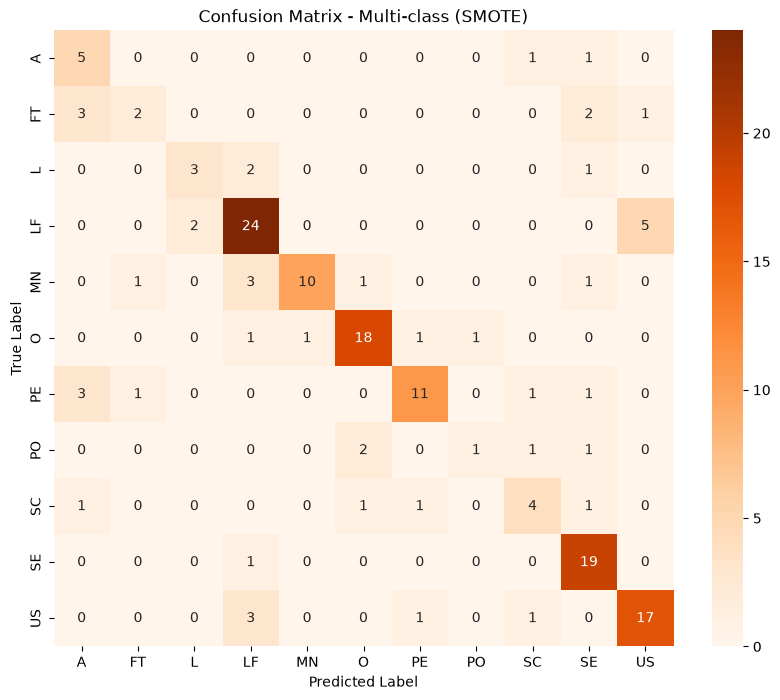

In [8]:
# Evaluate SMOTE Model on Test NFRs
test_nfr_mask = (test_df['label_binary'] == 'NFR').values
X_test_nfr_tfidf = X_test_tfidf[test_nfr_mask]
y_test_nfr = test_df.loc[test_nfr_mask, 'sub_NFR'].reset_index(drop=True)

y_pred_nfr = svm_multi.predict(X_test_nfr_tfidf)

acc_multi = accuracy_score(y_test_nfr, y_pred_nfr)
print(f"Accuracy (Sub-NFR Multi-class - SMOTE): {acc_multi:.4f}")
print("\nClassification Report (Sub-NFR - SMOTE):")
print(classification_report(y_test_nfr, y_pred_nfr))

# Confusion Matrix
labels = np.unique(y_test_nfr)
cm_multi = confusion_matrix(y_test_nfr, y_pred_nfr, labels=labels)
plt.figure(figsize=(10,8))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Oranges', xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix - Multi-class (SMOTE)")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## 4.b Alternative: Multi-class Classification with Class Weights (No SMOTE)
Let's compare the SMOTE approach with the built-in `class_weight='balanced'` approach to see which yields better metrics for minority classes.

In [9]:
svm_multi_cw = SVC(kernel='linear', decision_function_shape='ovr', class_weight='balanced', random_state=42)

start_time = time.time()
svm_multi_cw.fit(X_train_nfr_tfidf, y_train_nfr)
train_time_multi_cw = time.time() - start_time

print(f"Multi-class Model (Class Weight) Training Time: {train_time_multi_cw:.4f} seconds")

Multi-class Model (Class Weight) Training Time: 0.1087 seconds


Accuracy (Class Weight NFR): 0.7222

Classification Report (Class Weight NFR):
              precision    recall  f1-score   support

           A       0.50      0.57      0.53         7
          FT       0.50      0.25      0.33         8
           L       0.71      0.83      0.77         6
          LF       0.75      0.77      0.76        31
          MN       0.91      0.62      0.74        16
           O       0.81      0.77      0.79        22
          PE       0.88      0.82      0.85        17
          PO       0.50      0.20      0.29         5
          SC       0.50      0.50      0.50         8
          SE       0.63      0.95      0.76        20
          US       0.74      0.77      0.76        22

    accuracy                           0.72       162
   macro avg       0.68      0.64      0.64       162
weighted avg       0.73      0.72      0.71       162



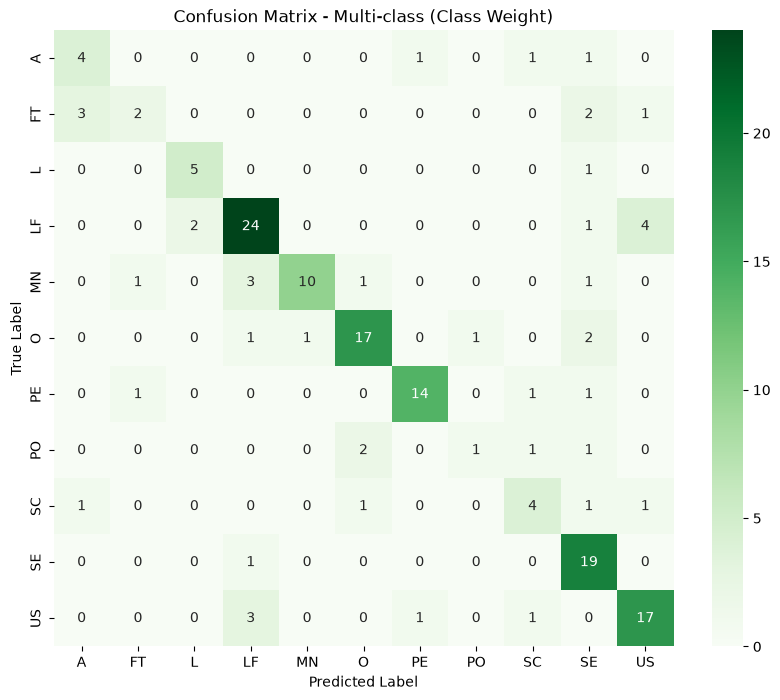

In [10]:
# Evaluate CW Model on Test NFRs
y_pred_nfr_cw = svm_multi_cw.predict(X_test_nfr_tfidf)

acc_multi_cw = accuracy_score(y_test_nfr, y_pred_nfr_cw)
print(f"Accuracy (Class Weight NFR): {acc_multi_cw:.4f}")
print("\nClassification Report (Class Weight NFR):")
print(classification_report(y_test_nfr, y_pred_nfr_cw))

# Confusion Matrix
cm_multi_cw = confusion_matrix(y_test_nfr, y_pred_nfr_cw, labels=labels)
plt.figure(figsize=(10,8))
sns.heatmap(cm_multi_cw, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix - Multi-class (Class Weight)")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## 5. End-to-End Inference Pipeline
A function that chains the TF-IDF, Binary SVM, and Multi-class SVM together. We use the `class_weight` model for multi-class since it yielded slightly better accuracy.

In [11]:
def predict_requirement(text):
    start = time.time()
    vec = vectorizer.transform([text])
    binary_pred = svm_binary.predict(vec)[0]
    
    if binary_pred == 'FR':
        final_label = 'FR'
    else:
        multi_pred = svm_multi_cw.predict(vec)[0]  # Using CW model because of better F1
        final_label = f"NFR - {multi_pred}"
        
    infer_time = time.time() - start
    return final_label, infer_time

sample_texts = [
    "The system shall allow users to upload profile pictures.",
    "The API must respond within 200 milliseconds under normal load.",
    "All passwords must be encrypted using SHA-256 before storing in the database.",
    "The user interface should be intuitive and easy to navigate for elderly users."
]

for t in sample_texts:
    pred, t_inf = predict_requirement(t)
    print(f"Text: {t}")
    print(f"Prediction: {pred} (Time: {t_inf*1000:.2f} ms)\n")

Text: The system shall allow users to upload profile pictures.
Prediction: FR (Time: 1.83 ms)

Text: The API must respond within 200 milliseconds under normal load.
Prediction: NFR - SE (Time: 1.32 ms)

Text: All passwords must be encrypted using SHA-256 before storing in the database.
Prediction: NFR - SE (Time: 1.23 ms)

Text: The user interface should be intuitive and easy to navigate for elderly users.
Prediction: NFR - US (Time: 0.91 ms)



## 6. Export Models
Save the vectorizer and trained models for future API/demo usage.

In [12]:
models_dir = '../models/baseline'
os.makedirs(models_dir, exist_ok=True)

joblib.dump(vectorizer, f"{models_dir}/tfidf_vectorizer.pkl")
joblib.dump(svm_binary, f"{models_dir}/svm_binary.pkl")
joblib.dump(svm_multi_cw, f"{models_dir}/svm_multiclass.pkl")  # Save CW model as the primary one

print(f"Models successfully exported to {models_dir}/")

Models successfully exported to ../models/baseline/
